## Bibliotecas 

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os # os é bom pra trabalhar com diretorios
import cv2 # import imghdr # pre processamento
import numpy as np
import glob
from sklearn.model_selection import train_test_split
from keras.layers import Dropout
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, Conv1D,MaxPooling1D
from tensorflow import keras
from IPython.display import Image
import pandas as pd
import mne
import os
import numpy as np
import gc
import fnmatch
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras_tuner import HyperModel
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from keras.utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt
import os # os é bom pra trabalhar com diretorios
import cv2 # import imghdr # pre processamento
import numpy as np
import pandas as pd
import keras_tuner as kt
import glob
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow import keras
from kerastuner import HyperModel
from kerastuner.tuners import RandomSearch
from kerastuner.tuners import Hyperband

import os
import fnmatch
import mne
import numpy as np
import gc

from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import shutil

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report


C:\Users\batis\AppData\Local\Temp\ipykernel_17904\3492502248.py:48: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperModel


## Leitura de dados

In [3]:
import mne
import numpy as np
import os
import fnmatch

def processar_arquivos(diretorio_raiz, lista_epocas, tarefas, limite_por_evento=None, quantidade_pessoas=None):
    """
    Adicionado o parâmetro quantidade_pessoas para limitar o número de sujeitos processados.
    """
    if not os.path.exists(diretorio_raiz):
        raise FileNotFoundError(f"O diretório raiz '{diretorio_raiz}' não foi encontrado.")

    pasta_pessoas = [p for p in os.listdir(diretorio_raiz) if os.path.isdir(os.path.join(diretorio_raiz, p))]
    
    # Aplica o limite de pessoas (sujeitos) se especificado
    # if quantidade_pessoas is not None:
    #     np.random.shuffle(pasta_pessoas)  # Embaralha para seleção aleatória
    #     pasta_pessoas = pasta_pessoas[:quantidade_pessoas]
    
    print("Quantidade de pessoas:", len(pasta_pessoas))
    
    canais_desejados = ['Fp1.', 'F7..', 'F3..', 'T7..', 'C3..', 'P7..', 'P3..', 'O1..',
                        'Fp2.', 'F4..', 'F8..', 'C4..', 'T8..', 'P4..', 'P8..', 'O2..']

    epocas_por_evento = {evento: [] for evento in lista_epocas}
    total_arquivos_eventos = {evento: 0 for evento in lista_epocas}

    for pessoa in pasta_pessoas:
        pasta_pessoa_atual = os.path.join(diretorio_raiz, pessoa)
        arquivos_edf = []
        for tarefa in tarefas:
            arquivos_edf.extend(fnmatch.filter(os.listdir(pasta_pessoa_atual), tarefa))
        
        print(f'Rodando arquivos da pessoa: {pessoa}')
        
        raws = []
        for arquivo_edf in arquivos_edf:
            arquivo_edf_atual = os.path.join(pasta_pessoa_atual, arquivo_edf)
            raw = mne.io.read_raw_edf(arquivo_edf_atual, preload=True)
            raw.pick_channels(canais_desejados)
            raws.append(raw)
        
        if raws:
            raw_concatenado = mne.concatenate_raws(raws)
            events, event_id = mne.events_from_annotations(raw_concatenado)

            for evento in lista_epocas:
                if evento in event_id:
                    epochs = mne.Epochs(raw_concatenado, events, event_id={evento: event_id[evento]}, 
                                        tmin=-0.5, tmax=4, baseline=(-0.5, 0))
                    epocas = epochs.get_data().astype(np.float32)

                    # Converte os dados para microvolts
                    epocas_microvolts = epocas * 1e6  # Conversão de volts para microvolts
                    epocas_por_evento[evento].extend(epocas_microvolts)
                    total_arquivos_eventos[evento] += len(epocas_microvolts)

    # Restante do código (limite por evento) permanece igual
    print("\n Quantidade de arquivos por evento ")
    for evento, quantidade in total_arquivos_eventos.items():
        print(f"{evento}: {quantidade} arquivos")

    if limite_por_evento is None:
        recomendacao = int(np.mean([q for q in total_arquivos_eventos.values() if q > 0]))
        print(f"\nRecomendação: Para equilibrar os dados, use um limite de aproximadamente {recomendacao} arquivos.")
        limite_por_evento = int(input("Digite o limite de arquivos por evento: "))
    
    for evento, epocas in epocas_por_evento.items():
        if len(epocas) > limite_por_evento:
            np.random.shuffle(epocas)  
            epocas_por_evento[evento] = epocas[:limite_por_evento]
            print(f'{evento} reduzido para {len(epocas_por_evento[evento])} arquivos')

    return epocas_por_evento


In [2]:
def normaliza(tensor):
    t1 = []
    for i in tensor:
        max_val = np.max(i)
        min_val = np.min(i)
        m = (i - min_val) / (max_val - min_val + 1e-8)  # evitar divisão por zero
        t1.append(m)
    return np.array(t1)


## Processamento de dados para o modelo de aprendizagem 

In [4]:
def separar_dados(epocas_por_evento):
    """
    Define x e y com os dados separados por evento,
    aplicando normalização por amostra (cada matriz é normalizada individualmente).
    """
    arrays = {}
    for evento, epocas in epocas_por_evento.items():
        arrays[evento] = np.array(epocas) if epocas else np.array([])
        print(f'{evento}_array shape:', arrays[evento].shape)

    del epocas_por_evento
    gc.collect()

    data = np.concatenate([array for array in arrays.values() if array.size > 0])
    print("Data shape:", data.shape)

    labels = []
    for i, (evento, array) in enumerate(arrays.items()):
        labels.extend([i] * len(array))

    del arrays
    gc.collect()

    x = np.nan_to_num(data)  # limpa NaNs
    y = np.array(labels)

    x = normaliza(x)  # 🔥 AQUI A MÁGICA

    print("Shape do x:", x.shape)
    print("Shape do y:", y.shape)
    print("Valores únicos em y:", np.unique(y))

    return x, y


In [10]:
x

array([[[0.42676774, 0.41936338, 0.43794802, ..., 0.33909553,
         0.3562937 , 0.33133718],
        [0.46260953, 0.54361486, 0.4355586 , ..., 0.31042212,
         0.341957  , 0.37195787],
        [0.539072  , 0.52927816, 0.45945308, ..., 0.3271483 ,
         0.3323992 , 0.4006313 ],
        ...,
        [0.39809433, 0.52927816, 0.46662146, ..., 0.4729048 ,
         0.49966076, 0.6037346 ],
        [0.4434939 , 0.6152984 , 0.53591555, ..., 0.5135255 ,
         0.5283342 , 0.65869206],
        [0.41959938, 0.51016253, 0.5239683 , ..., 0.45617864,
         0.463819  , 0.6563025 ]],

       [[0.39643463, 0.5042445 , 0.5203499 , ..., 0.55340976,
         0.55510753, 0.6131391 ],
        [0.40407473, 0.5137946 , 0.5356301 , ..., 0.5132994 ,
         0.5016271 , 0.5405584 ],
        [0.44036505, 0.5137946 , 0.5375401 , ..., 0.5228495 ,
         0.51881725, 0.50044805],
        ...,
        [0.68866724, 0.46795416, 0.42675912, ..., 0.42925864,
         0.41949636, 0.5233683 ],
        [0.6

In [11]:
x_min = np.array(x).min()
x_max = np.array(x).max()
print("Shape x_min",x_min.shape)
print("Shape x_max",x_max.shape)
print("x_min e max",x_min,x_max)

Shape x_min ()
Shape x_max ()
x_min e max 0.0 1.0


## "FAZAÇÃO" DO CÓDIGO HORA DE RODAR E REZAR

In [6]:
diretorio = r"C:\Users\batis\OneDrive\Área de Trabalho\Códigos diversos\Faculdade\BCI\Dados BRUTOS\files"
lista = ["T1", "T2"]
tarefas = ["*R04.edf", "*R08.edf", "*R12.edf"]

epocas = processar_arquivos(diretorio, lista, tarefas, quantidade_pessoas=84) #Para fazer o transferlearning vou colocar apenas 84 pessoas pro modelo (sabendo que tem 92 pessoas no total 8 pessoas vão ficar para realizar o trasnfer learning)
x, y = separar_dados(epocas)

Quantidade de pessoas: 92
Rodando arquivos da pessoa: S001
Extracting EDF parameters from C:\Users\batis\OneDrive\Área de Trabalho\Códigos diversos\Faculdade\BCI\Dados BRUTOS\files\S001\S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Extracting EDF parameters from C:\Users\batis\OneDrive\Área de Trabalho\Códigos diversos\Faculdade\BCI\Dados BRUTOS\files\S001\S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Extracting EDF parameters from C:\Users\batis\OneDrive\Área de Trabalho\Códigos diversos\Faculdade\BCI\Dados BRUTOS\files\S001\S001R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structu

## Split dos dados 

In [9]:
print(x)

[[[0.42676774 0.41936338 0.43794802 ... 0.33909553 0.3562937  0.33133718]
  [0.46260953 0.54361486 0.4355586  ... 0.31042212 0.341957   0.37195787]
  [0.539072   0.52927816 0.45945308 ... 0.3271483  0.3323992  0.4006313 ]
  ...
  [0.39809433 0.52927816 0.46662146 ... 0.4729048  0.49966076 0.6037346 ]
  [0.4434939  0.6152984  0.53591555 ... 0.5135255  0.5283342  0.65869206]
  [0.41959938 0.51016253 0.5239683  ... 0.45617864 0.463819   0.6563025 ]]

 [[0.39643463 0.5042445  0.5203499  ... 0.55340976 0.55510753 0.6131391 ]
  [0.40407473 0.5137946  0.5356301  ... 0.5132994  0.5016271  0.5405584 ]
  [0.44036505 0.5137946  0.5375401  ... 0.5228495  0.51881725 0.50044805]
  ...
  [0.68866724 0.46795416 0.42675912 ... 0.42925864 0.41949636 0.5233683 ]
  [0.68675727 0.50997454 0.45540938 ... 0.469369   0.4233164  0.57684875]
  [0.75933784 0.56345505 0.52608    ... 0.50565934 0.46533677 0.5959489 ]]

 [[0.5118294  0.5108763  0.526574   ... 0.47123957 0.48337728 0.4459831 ]
  [0.4823121  0.501794

In [8]:
x=x.transpose(0,2,1)
print(x.shape)

(4140, 721, 16)


In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.10)

## CAMADA UTILIZADA PARA TREINO DO MODELO COM MAIOR ACURACIA 



In [13]:
import tensorflow as tf
from tensorflow import keras
from kerastuner import HyperModel

METRICS = [
    keras.metrics.TruePositives(name='tp'),
    keras.metrics.FalsePositives(name='fp'),
    keras.metrics.TrueNegatives(name='tn'),
    keras.metrics.FalseNegatives(name='fn'),
    keras.metrics.BinaryAccuracy(name='accuracy'),
    keras.metrics.Precision(name='precision'),
    keras.metrics.Recall(name='recall'),
    keras.metrics.AUC(name='auc'),
]
class CNNHyperModel(HyperModel):
    def __init__(self, input_shape, num_classes):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):
        model = keras.Sequential()

        # Primeira camada Conv1D atuando sobre os eletrodos (eixo Y)
        model.add(
            Conv1D(
                filters=hp.Int('filters', min_value=20, max_value=60, step=10, default=40),
                kernel_size=3,  # Reduzi para capturar melhor as relações entre eletrodos
                activation='relu',
                input_shape=self.input_shape
            )
        )

        # Segunda camada Conv1D atuando no tempo (eixo X)
        model.add(
            Conv1D(
                filters=hp.Int('filters', min_value=20, max_value=60, step=10, default=40),
                kernel_size=hp.Int('kernel_size', min_value=2, max_value=6, step=2, default=4),  
                activation='relu'
            )
        )

        # MaxPooling1D apenas na dimensão do tempo
        model.add(
            MaxPooling1D(
                pool_size=2,
                strides=1,
                padding='same'
            )
        )

        print(model.output_shape)  # Debug: verificar a saída antes do Flatten
        
        model.add(Flatten())

        model.add(
            Dense(
                units=hp.Int('units_dense', min_value=40, max_value=120, step=20, default=80),
                activation='relu'
            )
        )

        # Saída binária
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            optimizer=tf.keras.optimizers.Adam(
                hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG', default=1e-3)
            ),
            loss='binary_crossentropy',
            metrics=METRICS
        )

        return model


## Hypermodel UM DOS 2 Q TA FUNCIONANDO VER QUAL É ACHO Q É O SEGUNDO 😭

In [2]:
import os
import numpy as np
import shutil
from sklearn.model_selection import StratifiedKFold
from kerastuner.tuners import RandomSearch
# Suponha que CNNHyperModel já esteja definido
# Se estiver usando binary_crossentropy, os rótulos devem ser binários (0 ou 1)
# e a última camada do seu modelo deve ser Dense(1, activation='sigmoid')

# Parâmetros
global_best_acc = -1.0
global_best_model_file = None  # Será atualizado com o nome do melhor modelo
global_best_fold = -1
SEED = 1
NUM_CLASSES = 2  # Usado para definir o número de classes (se usar one-hot; caso contrário, não é necessário)
MAX_TRIALS = 2        
EXECUTION_PER_TRIAL = 1  # Testes rápidos – ajuste para treinamento final
INPUT_SHAPE = (721,16)

# Garantir que a pasta de checkpoints exista
os.makedirs("checkpoints", exist_ok=True)

skfold = StratifiedKFold(n_splits=30, shuffle=True, random_state=SEED)
fold_index = 0

for train_index, test_index in skfold.split(X_train, Y_train):
    fold_index += 1
    x_train, x_test = X_train[train_index], X_train[test_index]
    y_train, y_test = Y_train[train_index], Y_train[test_index]
    # Se estiver usando binary_crossentropy, mantenha os rótulos como 0 ou 1.
    # Se for categorical_crossentropy, converta com to_categorical.
    
    # Configuração do HyperModel e do Tuner
    hypermodel = CNNHyperModel(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
    tuner = RandomSearch(
        hypermodel,
        objective='val_accuracy',
        seed=SEED,
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTION_PER_TRIAL,
        overwrite=True
    )
    tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=0)
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = hypermodel.build(best_hps)
    
    # Treinar o modelo para este fold
    history = best_model.fit(x_train, y_train, epochs=13, validation_data=(x_test, y_test), verbose=0)
    fold_best_val_acc = max(history.history['val_accuracy'])
    print(f"Fold {fold_index}: Best val_accuracy = {fold_best_val_acc:.4f}")
    
    # Se a acurácia deste fold for melhor que a global, atualiza o modelo global
    if fold_best_val_acc > global_best_acc:
        global_best_acc = fold_best_val_acc
        global_best_fold = fold_index
        # Cria um nome de arquivo que inclua o valor da acurácia
        new_filename = f"checkpoints/melhor_modelo_fold_{fold_index}_acc_{global_best_acc:.4f}.h5"
        best_model.save(new_filename)
        global_best_model_file = new_filename
        print(f"🔥 Novo melhor modelo global: Fold {fold_index} com acurácia {global_best_acc:.4f} salvo em {new_filename}")

print(f"Melhor fold global: {global_best_fold} com val_accuracy = {global_best_acc:.4f}")
print(f"Modelo global salvo em: {global_best_model_file}")


NameError: name 'X_train' is not defined

In [23]:
import os
import shutil

global_best_acc = -1.0
global_best_model_file = None
global_best_fold = -1
SEED = 1
NUM_CLASSES = 2
MAX_TRIALS = 2        
EXECUTION_PER_TRIAL = 1  # Aumentar para o treinamento final
INPUT_SHAPE = (721,16)

skfold = StratifiedKFold(n_splits=30, shuffle=True, random_state=SEED)
fold_index = 0

for train_index, test_index in skfold.split(X_train, Y_train):
    fold_index += 1
    x_train, x_test = X_train[train_index], X_train[test_index]
    y_train, y_test = Y_train[train_index], Y_train[test_index]
    
    hypermodel = CNNHyperModel(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
    tuner = RandomSearch(
        hypermodel,
        objective='val_accuracy',
        seed=SEED,
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTION_PER_TRIAL,
        overwrite=True
    )
    tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=0)
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = hypermodel.build(best_hps)
    
    # Define nome do arquivo para o fold atual (arquivo temporário)
    fold_model_file = f"melhor_modelo_fold_{fold_index}.h5"
    checkpoint = ModelCheckpoint(
        fold_model_file,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    history = best_model.fit(x_train, y_train, epochs=13, validation_data=(x_test, y_test), callbacks=[checkpoint])
    best_model.load_weights(fold_model_file)
    
    best_val_acc = max(history.history['val_accuracy'])
    print(f"Fold {fold_index}: Best val_accuracy = {best_val_acc:.4f}")
    
    # 🔹 Se esse modelo for melhor que o global, ele será salvo
    if best_val_acc > global_best_acc:
        global_best_acc = best_val_acc
        global_best_fold = fold_index
        global_best_model_file = f"melhor_modelo_{global_best_acc:.4f}.h5"
        
        # Salva o melhor modelo global e remove o anterior se existir
        if os.path.exists(global_best_model_file):
            os.remove(global_best_model_file)
        shutil.copyfile(fold_model_file, global_best_model_file)
        
        print(f"🔥 Novo melhor modelo global salvo: {global_best_model_file} com val_accuracy: {global_best_acc:.4f}")

    # Remove o arquivo temporário do fold
    os.remove(fold_model_file)

print(f"✅ Melhor modelo salvo: {global_best_model_file} com val_accuracy = {global_best_acc:.4f}")


c:\Users\batis\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(None, 716, 40)
(None, 714, 20)
(None, 714, 50)
(None, 714, 20)
Epoch 1/13
102/109 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5099 - auc: 0.5127 - fn: 440.7353 - fp: 432.6667 - loss: 0.7740 - precision: 0.4946 - recall: 0.4522 - tn: 468.2255 - tp: 426.3726
Epoch 1: val_accuracy improved from -inf to 0.49167, saving model to melhor_modelo_fold_1.h5


109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5095 - auc: 0.5123 - fn: 468.8727 - fp: 467.9000 - loss: 0.7702 - precision: 0.4952 - recall: 0.4577 - tn: 495.9636 - tp: 462.8273 - val_accuracy: 0.4917 - val_auc: 0.6546 - val_fn: 0.0000e+00 - val_fp: 61.0000 - val_loss: 0.6984 - val_precision: 0.4917 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 59.0000
Epoch 2/13
107/109 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5223 - auc: 0.5209 - fn: 386.6542 - fp: 440.1963 - loss: 0.6943 - precision: 0.5190 - recall: 0.6246 - tn: 426.6449 - tp: 474.5047
Epoch 2: val_accuracy did not improve from 0.49167
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5221 - auc: 0.5209 - fn: 400.3546 - fp: 449.9818 - loss: 0.6943 - precision: 0.5189 - recall: 0.6209 - tn: 440.5909 - tp: 484.6364 - val_accuracy: 0.4917 - val_auc: 0.7912 - val_fn: 0.0000e+00 - val_fp: 61.0000 - val_loss: 0.6893 - val_precision: 0.4917 - val_recall: 1.0000 - val_tn: 0.0000e+00 - val_tp: 59.0000
Epoch 3/13
10

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5567 - auc: 0.5930 - fn: 317.5818 - fp: 457.7636 - loss: 0.6857 - precision: 0.5525 - recall: 0.7161 - tn: 421.3182 - tp: 578.9000 - val_accuracy: 0.7417 - val_auc: 0.8176 - val_fn: 11.0000 - val_fp: 20.0000 - val_loss: 0.6679 - val_precision: 0.7059 - val_recall: 0.8136 - val_tn: 41.0000 - val_tp: 48.0000
Epoch 4/13
107/109 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6507 - auc: 0.7215 - fn: 306.3925 - fp: 302.5794 - loss: 0.6643 - precision: 0.6572 - recall: 0.6417 - tn: 564.5888 - tp: 554.4393
Epoch 4: val_accuracy did not improve from 0.74167
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6512 - auc: 0.7219 - fn: 313.7727 - fp: 310.2273 - loss: 0.6640 - precision: 0.6574 - recall: 0.6424 - tn: 580.6818 - tp: 570.8818 - val_accuracy: 0.6750 - val_auc: 0.8429 - val_fn: 35.0000 - val_fp: 4.0000 - val_loss: 0.6111 - val_precision: 0.8571 - val_recall: 0.4068 - val_tn: 57.0000 - val_tp: 24.0000
Epoch 5/13
107/109 ━━━━━━━━

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7383 - auc: 0.8363 - fn: 212.3818 - fp: 227.5364 - loss: 0.5196 - precision: 0.7261 - recall: 0.7473 - tn: 666.7000 - tp: 668.9454 - val_accuracy: 0.8167 - val_auc: 0.8800 - val_fn: 10.0000 - val_fp: 12.0000 - val_loss: 0.4605 - val_precision: 0.8033 - val_recall: 0.8305 - val_tn: 49.0000 - val_tp: 49.0000
Epoch 7/13
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7974 - auc: 0.8838 - fn: 193.4587 - fp: 176.0734 - loss: 0.4501 - precision: 0.8029 - recall: 0.7841 - tn: 711.4679 - tp: 678.9266
Epoch 7: val_accuracy did not improve from 0.81667
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7973 - auc: 0.8838 - fn: 195.1818 - fp: 177.7091 - loss: 0.4501 - precision: 0.8028 - recall: 0.7840 - tn: 717.5909 - tp: 685.0818 - val_accuracy: 0.8083 - val_auc: 0.8923 - val_fn: 9.0000 - val_fp: 14.0000 - val_loss: 0.4257 - val_precision: 0.7812 - val_recall: 0.8475 - val_tn: 47.0000 - val_tp: 50.0000
Epoch 8/13
108/109 ━━━━━━━━

...

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7339 - auc: 0.8319 - fn: 261.0636 - fp: 192.7273 - loss: 0.5548 - precision: 0.7718 - recall: 0.6560 - tn: 704.8818 - tp: 616.8909 - val_accuracy: 0.8083 - val_auc: 0.9110 - val_fn: 20.0000 - val_fp: 3.0000 - val_loss: 0.4629 - val_precision: 0.9302 - val_recall: 0.6667 - val_tn: 57.0000 - val_tp: 40.0000
Epoch 4/13
108/109 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7971 - auc: 0.8810 - fn: 179.8333 - fp: 170.7963 - loss: 0.4612 - precision: 0.8130 - recall: 0.7849 - tn: 692.3426 - tp: 701.0278
Epoch 4: val_accuracy improved from 0.80833 to 0.82500, saving model to melhor_modelo_fold_30.h5


109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7971 - auc: 0.8811 - fn: 182.8545 - fp: 173.9636 - loss: 0.4609 - precision: 0.8128 - recall: 0.7852 - tn: 705.1545 - tp: 713.5909 - val_accuracy: 0.8250 - val_auc: 0.9253 - val_fn: 20.0000 - val_fp: 1.0000 - val_loss: 0.4080 - val_precision: 0.9756 - val_recall: 0.6667 - val_tn: 59.0000 - val_tp: 40.0000
Epoch 5/13
107/109 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8038 - auc: 0.8931 - fn: 172.0935 - fp: 169.0187 - loss: 0.4251 - precision: 0.8153 - recall: 0.7843 - tn: 698.4860 - tp: 688.4019
Epoch 5: val_accuracy did not improve from 0.82500
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8037 - auc: 0.8930 - fn: 176.8455 - fp: 173.9454 - loss: 0.4251 - precision: 0.8149 - recall: 0.7847 - tn: 717.3273 - tp: 707.4454 - val_accuracy: 0.8000 - val_auc: 0.9329 - val_fn: 23.0000 - val_fp: 1.0000 - val_loss: 0.4147 - val_precision: 0.9737 - val_recall: 0.6167 - val_tn: 59.0000 - val_tp: 37.0000
Epoch 6/13
108/109 ━━━━━━

109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8111 - auc: 0.8999 - fn: 164.7818 - fp: 167.5546 - loss: 0.4078 - precision: 0.8218 - recall: 0.8091 - tn: 706.9636 - tp: 736.2636 - val_accuracy: 0.8333 - val_auc: 0.9296 - val_fn: 14.0000 - val_fp: 6.0000 - val_loss: 0.3802 - val_precision: 0.8846 - val_recall: 0.7667 - val_tn: 54.0000 - val_tp: 46.0000
Epoch 7/13
107/109 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8244 - auc: 0.9133 - fn: 157.2804 - fp: 156.3458 - loss: 0.3800 - precision: 0.8313 - recall: 0.8216 - tn: 695.1869 - tp: 719.1869
Epoch 7: val_accuracy improved from 0.83333 to 0.84167, saving model to melhor_modelo_fold_30.h5


109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8240 - auc: 0.9129 - fn: 161.8909 - fp: 161.0818 - loss: 0.3807 - precision: 0.8307 - recall: 0.8213 - tn: 714.6273 - tp: 737.9636 - val_accuracy: 0.8417 - val_auc: 0.9239 - val_fn: 14.0000 - val_fp: 5.0000 - val_loss: 0.3651 - val_precision: 0.9020 - val_recall: 0.7667 - val_tn: 55.0000 - val_tp: 46.0000
Epoch 8/13
108/109 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8060 - auc: 0.8889 - fn: 166.1389 - fp: 164.6204 - loss: 0.4241 - precision: 0.8014 - recall: 0.7946 - tn: 723.2130 - tp: 690.0278
Epoch 8: val_accuracy improved from 0.84167 to 0.85000, saving model to melhor_modelo_fold_30.h5


109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8062 - auc: 0.8891 - fn: 168.7364 - fp: 167.6636 - loss: 0.4238 - precision: 0.8015 - recall: 0.7951 - tn: 735.7000 - tp: 703.4636 - val_accuracy: 0.8500 - val_auc: 0.9321 - val_fn: 14.0000 - val_fp: 4.0000 - val_loss: 0.3682 - val_precision: 0.9200 - val_recall: 0.7667 - val_tn: 56.0000 - val_tp: 46.0000
Epoch 9/13
108/109 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8172 - auc: 0.9070 - fn: 165.8704 - fp: 163.2315 - loss: 0.3916 - precision: 0.8193 - recall: 0.8134 - tn: 710.3055 - tp: 704.5926
Epoch 9: val_accuracy did not improve from 0.85000
109/109 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8172 - auc: 0.9069 - fn: 168.7091 - fp: 166.1909 - loss: 0.3918 - precision: 0.8192 - recall: 0.8134 - tn: 723.1364 - tp: 717.5273 - val_accuracy: 0.8417 - val_auc: 0.9296 - val_fn: 12.0000 - val_fp: 7.0000 - val_loss: 0.3582 - val_precision: 0.8727 - val_recall: 0.8000 - val_tn: 53.0000 - val_tp: 48.0000
Epoch 10/13
106/109 ━━━━━

In [14]:
import os
import shutil
import pickle
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from sklearn.model_selection import StratifiedKFold
from kerastuner import RandomSearch
import tensorflow as tf

# Global variables
global_best_acc = -1.0
global_best_model_file = None
global_best_fold = -1
SEED = 1
NUM_CLASSES = 2
MAX_TRIALS = 2        
EXECUTION_PER_TRIAL = 1  
INPUT_SHAPE = (721, 16)

# Initialize StratifiedKFold
skfold = StratifiedKFold(n_splits=30, shuffle=True, random_state=SEED)
fold_index = 0

# Loop over each fold
for train_index, test_index in skfold.split(X_train, Y_train):
    fold_index += 1
    x_train, x_test = X_train[train_index], X_train[test_index]
    y_train, y_test = Y_train[train_index], Y_train[test_index]
    
    # Initialize HyperModel and RandomSearch tuner
    hypermodel = CNNHyperModel(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)
    tuner = RandomSearch(
        hypermodel,
        objective='val_accuracy',
        seed=SEED,
        max_trials=MAX_TRIALS,
        executions_per_trial=EXECUTION_PER_TRIAL,
        overwrite=True
    )
    
    # Perform the search for best hyperparameters
    tuner.search(x_train, y_train, epochs=5, validation_data=(x_test, y_test), verbose=0)
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    best_model = hypermodel.build(best_hps)
    
    # Define checkpoint for saving the best model during training
    fold_model_file = f"melhor_modelo_fold_{fold_index}.h5"
    checkpoint = ModelCheckpoint(
        fold_model_file,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    # Train the model
    history = best_model.fit(x_train, y_train, epochs=13, validation_data=(x_test, y_test), callbacks=[checkpoint])
    best_model.load_weights(fold_model_file)
    
    # Get the best validation accuracy for this fold
    best_val_acc = max(history.history['val_accuracy'])
    print(f"Fold {fold_index}: Best val_accuracy = {best_val_acc:.4f}")
    
    # Save the best model if it has better validation accuracy
    if best_val_acc > global_best_acc:
        global_best_acc = best_val_acc
        global_best_fold = fold_index
        global_best_model_file = f"melhor_modelo_{global_best_acc:.4f}.h5"
        
        # Remove previous model if it exists and save the current best model
        if os.path.exists(global_best_model_file):
            os.remove(global_best_model_file)
        shutil.copyfile(fold_model_file, global_best_model_file)
        
        print(f"🔥 Novo melhor modelo global salvo: {global_best_model_file} com val_accuracy: {global_best_acc:.4f}")
    
    # Save the history of the best model to a pickle file
    with open(f"historico_fold_{fold_index}.pkl", 'wb') as f:
        pickle.dump(history.history, f)
    
    # Remove temporary fold model file
    os.remove(fold_model_file)

# Final output for the best model
print(f"✅ Melhor modelo salvo: {global_best_model_file} com val_accuracy = {global_best_acc:.4f}")


c:\Users\batis\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(None, 716, 40)

(None, 714, 20)
(None, 714, 50)
(None, 714, 20)
Epoch 1/13
107/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5626 - auc: 0.5989 - fn: 775.3552 - fp: 62.2617 - loss: 0.7179 - precision: 0.6891 - recall: 0.2247 - tn: 875.3925 - tp: 139.9907
Epoch 1: val_accuracy improved from -inf to 0.64000, saving model to melhor_modelo_fold_1.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5616 - auc: 0.5984 - fn: 823.8421 - fp: 64.3684 - loss: 0.7166 - precision: 0.6912 - recall: 0.2194 - tn: 929.3246 - tp: 146.9211 - val_accuracy: 0.6400 - val_auc: 0.7663 - val_fn: 38.0000 - val_fp: 7.0000 - val_loss: 0.6854 - val_precision: 0.7742 - val_recall: 0.3871 - val_tn: 56.0000 - val_tp: 24.0000
Epoch 2/13
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5813 - auc: 0.6953 - fn: 659.0982 - fp: 85.8036 - loss: 0.6738 - precision: 0.7999 - recall: 0.2190 - tn: 835.6696 - tp: 227.4286
Epoch 2: val_accuracy improved from 0.64000 to 0.78400, saving model to melhor_modelo_fold_1.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5819 - auc: 0.6953 - fn: 666.5877 - fp: 89.5088 - loss: 0.6734 - precision: 0.7982 - recall: 0.2220 - tn: 847.6404 - tp: 235.7193 - val_accuracy: 0.7840 - val_auc: 0.8539 - val_fn: 20.0000 - val_fp: 7.0000 - val_loss: 0.5649 - val_precision: 0.8571 - val_recall: 0.6774 - val_tn: 56.0000 - val_tp: 42.0000
Epoch 3/13
110/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7766 - auc: 0.8530 - fn: 213.7818 - fp: 179.3091 - loss: 0.5096 - precision: 0.7835 - recall: 0.7484 - tn: 734.9545 - tp: 647.9545
Epoch 3: val_accuracy did not improve from 0.78400
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7768 - auc: 0.8534 - fn: 220.3860 - fp: 186.2281 - loss: 0.5084 - precision: 0.7835 - recall: 0.7492 - tn: 759.3684 - tp: 673.4737 - val_accuracy: 0.7520 - val_auc: 0.8642 - val_fn: 11.0000 - val_fp: 20.0000 - val_loss: 0.4664 - val_precision: 0.7183 - val_recall: 0.8226 - val_tn: 43.0000 - val_tp: 51.0000
Epoch 4/13
106/113 ━━━━━━━━━

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8120 - auc: 0.8940 - fn: 175.5175 - fp: 174.3860 - loss: 0.4181 - precision: 0.8071 - recall: 0.8095 - tn: 761.9035 - tp: 727.6491 - val_accuracy: 0.8000 - val_auc: 0.8830 - val_fn: 10.0000 - val_fp: 15.0000 - val_loss: 0.4396 - val_precision: 0.7761 - val_recall: 0.8387 - val_tn: 48.0000 - val_tp: 52.0000
Epoch 5/13
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8120 - auc: 0.8927 - fn: 160.9196 - fp: 171.0893 - loss: 0.4155 - precision: 0.8050 - recall: 0.8188 - tn: 734.1607 - tp: 741.8304
Epoch 5: val_accuracy improved from 0.80000 to 0.81600, saving model to melhor_modelo_fold_1.h5


...

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8471 - auc: 0.9285 - fn: 139.6140 - fp: 135.5877 - loss: 0.3435 - precision: 0.8448 - recall: 0.8389 - tn: 800.8509 - tp: 763.4211 - val_accuracy: 0.8226 - val_auc: 0.9063 - val_fn: 12.0000 - val_fp: 10.0000 - val_loss: 0.3926 - val_precision: 0.8305 - val_recall: 0.8033 - val_tn: 53.0000 - val_tp: 49.0000
Epoch 7/13
111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8498 - auc: 0.9282 - fn: 134.3423 - fp: 127.2342 - loss: 0.3432 - precision: 0.8566 - recall: 0.8475 - tn: 769.2883 - tp: 761.1351
Epoch 7: val_accuracy did not improve from 0.82258
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8500 - auc: 0.9284 - fn: 137.5702 - fp: 130.6667 - loss: 0.3428 - precision: 0.8566 - recall: 0.8477 - tn: 789.9386 - tp: 781.2982 - val_accuracy: 0.8226 - val_auc: 0.9088 - val_fn: 11.0000 - val_fp: 11.0000 - val_loss: 0.3883 - val_precision: 0.8197 - val_recall: 0.8197 - val_tn: 52.0000 - val_tp: 50.0000
Epoch 8/13
112/113 ━━━━

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8705 - auc: 0.9392 - fn: 123.8509 - fp: 125.7368 - loss: 0.3186 - precision: 0.8731 - recall: 0.8710 - tn: 795.1053 - tp: 794.7807 - val_accuracy: 0.8306 - val_auc: 0.9094 - val_fn: 8.0000 - val_fp: 13.0000 - val_loss: 0.3941 - val_precision: 0.8030 - val_recall: 0.8689 - val_tn: 50.0000 - val_tp: 53.0000
Epoch 9/13
111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8739 - auc: 0.9483 - fn: 115.0180 - fp: 114.7568 - loss: 0.2938 - precision: 0.8682 - recall: 0.8745 - tn: 794.5766 - tp: 767.6486
Epoch 9: val_accuracy did not improve from 0.83065
113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8739 - auc: 0.9482 - fn: 118.0614 - fp: 117.7368 - loss: 0.2941 - precision: 0.8683 - recall: 0.8744 - tn: 815.3158 - tp: 788.3596 - val_accuracy: 0.7984 - val_auc: 0.9009 - val_fn: 9.0000 - val_fp: 16.0000 - val_loss: 0.4112 - val_precision: 0.7647 - val_recall: 0.8525 - val_tn: 47.0000 - val_tp: 52.0000
Epoch 10/13
111/113 ━━━━━

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6515 - auc: 0.7212 - fn: 209.1579 - fp: 437.4825 - loss: 0.6366 - precision: 0.6256 - recall: 0.8016 - tn: 540.1842 - tp: 776.6491 - val_accuracy: 0.7903 - val_auc: 0.8963 - val_fn: 7.0000 - val_fp: 19.0000 - val_loss: 0.4358 - val_precision: 0.7397 - val_recall: 0.8852 - val_tn: 44.0000 - val_tp: 54.0000
Epoch 2/13
110/113 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7881 - auc: 0.8805 - fn: 188.1091 - fp: 179.1364 - loss: 0.4362 - precision: 0.7831 - recall: 0.7790 - tn: 724.3273 - tp: 684.4272
Epoch 2: val_accuracy improved from 0.79032 to 0.84677, saving model to melhor_modelo_fold_30.h5


113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7884 - auc: 0.8807 - fn: 194.3246 - fp: 185.3158 - loss: 0.4360 - precision: 0.7837 - recall: 0.7795 - tn: 749.8246 - tp: 710.0088 - val_accuracy: 0.8468 - val_auc: 0.9054 - val_fn: 15.0000 - val_fp: 4.0000 - val_loss: 0.4162 - val_precision: 0.9200 - val_recall: 0.7541 - val_tn: 59.0000 - val_tp: 46.0000
Epoch 3/13
107/113 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8118 - auc: 0.8932 - fn: 158.7570 - fp: 155.8878 - loss: 0.4141 - precision: 0.8201 - recall: 0.8046 - tn: 703.8224 - tp: 709.5327
Epoch 3: val_accuracy did not improve from 0.84677
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8121 - auc: 0.8936 - fn: 168.9474 - fp: 166.1404 - loss: 0.4135 - precision: 0.8199 - recall: 0.8053 - tn: 750.2895 - tp: 754.0965 - val_accuracy: 0.8387 - val_auc: 0.9127 - val_fn: 14.0000 - val_fp: 6.0000 - val_loss: 0.3820 - val_precision: 0.8868 - val_recall: 0.7705 - val_tn: 57.0000 - val_tp: 47.0000
Epoch 4/13
106/113 ━━━━━━━━━

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8509 - auc: 0.9280 - fn: 133.8772 - fp: 137.4561 - loss: 0.3435 - precision: 0.8493 - recall: 0.8545 - tn: 792.2719 - tp: 775.8684 - val_accuracy: 0.8629 - val_auc: 0.9163 - val_fn: 13.0000 - val_fp: 4.0000 - val_loss: 0.3740 - val_precision: 0.9231 - val_recall: 0.7869 - val_tn: 59.0000 - val_tp: 48.0000
Epoch 10/13
112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8532 - auc: 0.9381 - fn: 134.3750 - fp: 119.4107 - loss: 0.3199 - precision: 0.8665 - recall: 0.8360 - tn: 787.6339 - tp: 766.5804
Epoch 10: val_accuracy did not improve from 0.86290
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8534 - auc: 0.9381 - fn: 136.4386 - fp: 121.5614 - loss: 0.3198 - precision: 0.8664 - recall: 0.8365 - tn: 801.4123 - tp: 780.0614 - val_accuracy: 0.8145 - val_auc: 0.9119 - val_fn: 15.0000 - val_fp: 8.0000 - val_loss: 0.3827 - val_precision: 0.8519 - val_recall: 0.7541 - val_tn: 55.0000 - val_tp: 46.0000
Epoch 11/13
110/113 ━━━━━━

## Gráfico e matriz confusão

✅ Carregando o modelo: C:\Users\batis\Downloads\checkpoints\melhor_modelo_fold_25_acc_0.8952.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


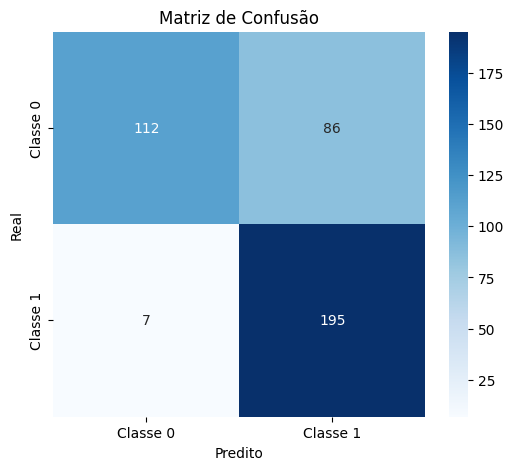

              precision    recall  f1-score   support

           0       0.94      0.57      0.71       198
           1       0.69      0.97      0.81       202

    accuracy                           0.77       400
   macro avg       0.82      0.77      0.76       400
weighted avg       0.82      0.77      0.76       400



In [10]:
# 🔹 Encontrar o arquivo do melhor modelo salvo
melhor_modelo_path = max(glob.glob(r"C:\Users\batis\Downloads\checkpoints\melhor_modelo_fold_25_acc_0.8952.h5"), key=os.path.getctime)

print(f"✅ Carregando o modelo: {melhor_modelo_path}")
melhor_modelo = load_model(melhor_modelo_path)

# 🔹 Fazer previsões nos dados de teste do melhor fold
y_pred_probs = melhor_modelo.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplica limiar de 0.5
y_true = Y_test  # Certifique-se de que y_test está no formato correto

# 🔹 Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 🔹 Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

# 🔹 Relatório de classificação
print(classification_report(y_true, y_pred))


In [18]:
import tensorflow as tf

# Ativar o eager execution
tf.compat.v1.enable_eager_execution()


In [19]:
history = melhor_modelo.fit(X_train, Y_train, epochs=13, validation_data=(X_test, Y_test))

Epoch 1/13


NotImplementedError: numpy() is only available when eager execution is enabled.

✅ Carregando o modelo: C:\Users\batis\Downloads\checkpoints\melhor_modelo_fold_25_acc_0.8952.h5
⚠️ Arquivo de histórico não encontrado. Você precisa treinar o modelo novamente para salvar o histórico.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


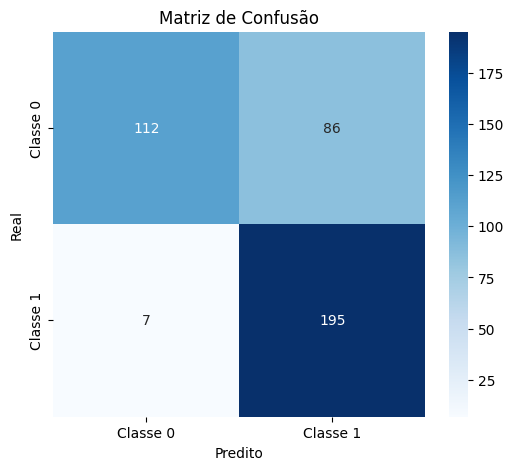

              precision    recall  f1-score   support

           0       0.94      0.57      0.71       198
           1       0.69      0.97      0.81       202

    accuracy                           0.77       400
   macro avg       0.82      0.77      0.76       400
weighted avg       0.82      0.77      0.76       400



In [12]:
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Encontrar o arquivo do melhor modelo salvo
melhor_modelo_path = max(glob.glob(r"C:\Users\batis\Downloads\checkpoints\melhor_modelo_fold_25_acc_0.8952.h5"), key=os.path.getctime)

print(f"✅ Carregando o modelo: {melhor_modelo_path}")
melhor_modelo = load_model(melhor_modelo_path)

# 🔹 Carregar histórico do treinamento se disponível
try:
    history = np.load(r"C:\Users\batis\Downloads\checkpoints\history.npy", allow_pickle=True).item()
except FileNotFoundError:
    print("⚠️ Arquivo de histórico não encontrado. Você precisa treinar o modelo novamente para salvar o histórico.")
    history = None

# 🔹 Fazer previsões nos dados de teste do melhor fold
y_pred_probs = melhor_modelo.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplica limiar de 0.5
y_true = Y_test  # Certifique-se de que y_test está no formato correto

# 🔹 Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 🔹 Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

# 🔹 Relatório de classificação
print(classification_report(y_true, y_pred))

# 🔹 Plotar o Gráfico de Treinamento (se o histórico existir)
if history:
    plt.figure(figsize=(12, 5))

    # 🔹 Gráfico da Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Acurácia Treinamento')
    plt.plot(history['val_accuracy'], label='Acurácia Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.title('Evolução da Acurácia')
    plt.legend()

    # 🔹 Gráfico da Perda
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Perda Treinamento')
    plt.plot(history['val_loss'], label='Perda Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.title('Evolução da Perda')
    plt.legend()

    plt.show()


In [ ]:
y_pred_probs = best_model.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplica limiar de 0.5
y_true = Y_test  # Certifique-se de que y_test está no formato correto

# 🔹 Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 🔹 Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

# 🔹 Relatório de classificação
print(classification_report(y_true, y_pred))

# 🔹 Plotar o Gráfico de Treinamento (se o histórico existir)
if history:
    plt.figure(figsize=(12, 5))

    # 🔹 Gráfico da Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Acurácia Treinamento')
    plt.plot(history['val_accuracy'], label='Acurácia Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.title('Evolução da Acurácia')
    plt.legend()

    # 🔹 Gráfico da Perda
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Perda Treinamento')
    plt.plot(history['val_loss'], label='Perda Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.title('Evolução da Perda')
    plt.legend()

    plt.show()


✅ Modelo carregado: melhor_modelo_0.9000.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


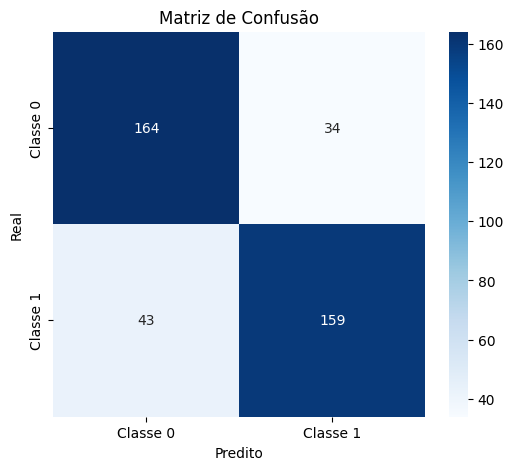

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       198
           1       0.82      0.79      0.81       202

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



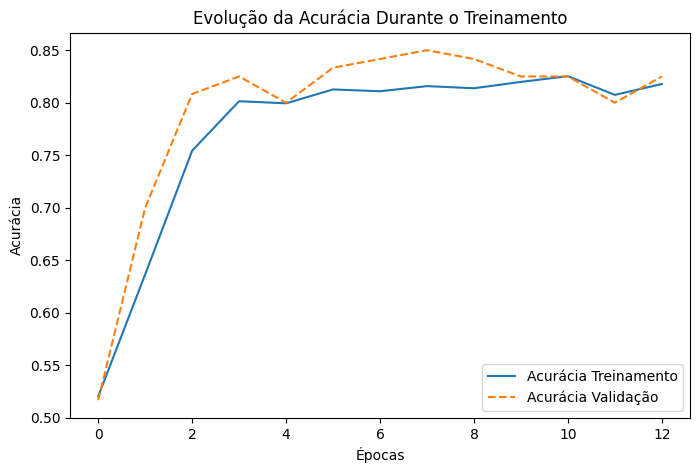

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Carregar o melhor modelo salvo
melhor_modelo = load_model(global_best_model_file)
print(f"✅ Modelo carregado: {global_best_model_file}")

# 🔹 Fazer previsões nos dados de teste
y_pred_probs = melhor_modelo.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplicar limiar de 0.5
y_true = Y_test  # Certifique-se de que Y_test está no formato correto

# 🔹 Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 🔹 Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

# 🔹 Exibir relatório de classificação
print(classification_report(y_true, y_pred))

# 🔹 Plotar a acurácia durante o treinamento
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Acurácia Treinamento")
plt.plot(history.history['val_accuracy'], label="Acurácia Validação", linestyle="--")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.title("Evolução da Acurácia Durante o Treinamento")
plt.show()


In [25]:
# Re-load the best model and continue training or test it with new data
# For example:
history = melhor_modelo.fit(X_train, Y_train, epochs=13, validation_data=(X_test, Y_test))

Epoch 1/13


NotImplementedError: numpy() is only available when eager execution is enabled.

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import numpy as np

# 1. Carregar o histórico salvo
with open(r"C:\Users\batis\Downloads\historico_fold_23.pkl", 'rb') as f:
    best_model_history = pickle.load(f)

# 2. Carregar o melhor modelo salvo
best_model = load_model(r"C:\Users\batis\Downloads\melhor_modelo_0.9000.h5")  # Substitua pelo nome do seu modelo

# 3. Plotar o gráfico de acurácia
train_accuracies = [best_model_history[fold]['train_accuracy'] for fold in best_model_history]
val_accuracies = [best_model_history[fold]['val_accuracy'] for fold in best_model_history]

plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Acurácia Treinamento')
plt.plot(val_accuracies, label='Acurácia Validação')
plt.title('Acurácia dos Melhores Modelos por Fold')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# 4. Fazer previsões nos dados de teste com o melhor modelo
y_pred_probs = best_model.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplica limiar de 0.5
y_true = Y_test  # Certifique-se de que y_test está no formato correto

# 5. Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 6. Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()


TypeError: list indices must be integers or slices, not str

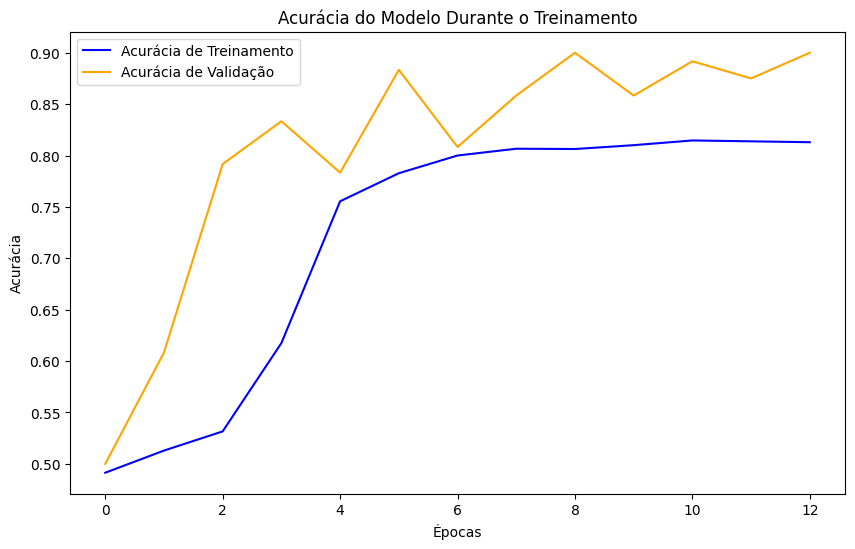

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


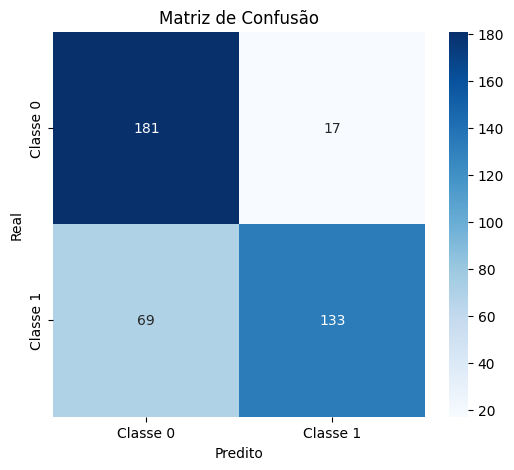

In [31]:
import pickle
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Carregar o histórico do arquivo .pkl
file_path = r"C:\Users\batis\Downloads\historico_fold_23.pkl"  # Substitua pelo caminho do seu arquivo
history_file = open(file_path, 'rb')
best_model_history = pickle.load(history_file)
history_file.close()

# 2. Extrair acurácias de treino e validação
train_accuracies = best_model_history['accuracy']
val_accuracies = best_model_history['val_accuracy']

# 3. Plotar o gráfico de acurácia
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Acurácia de Treinamento', color='blue')
plt.plot(val_accuracies, label='Acurácia de Validação', color='orange')
plt.title('Acurácia do Modelo Durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# 4. Carregar o melhor modelo salvo
best_model = load_model(r"C:\Users\batis\Downloads\melhor_modelo_0.9000.h5")  # Substitua pelo seu caminho

# 5. Gerar a matriz de confusão
# Supondo que X_test e Y_test sejam seus dados de teste
y_pred_probs = best_model.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplica limiar de 0.5
y_true = Y_test  # Certifique-se de que Y_test está no formato correto

# Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model
import numpy as np

# 1. Carregar o histórico salvo
with open(r"C:\Users\batis\Downloads\historico_fold_23.pkl", 'rb') as f:
    best_model_history = pickle.load(f)

# 2. Carregar o melhor modelo salvo
best_model = load_model(r"C:\Users\batis\Downloads\melhor_modelo_0.9000.h5")  # Substitua pelo nome do seu modelo

# 3. Plotar o gráfico de acurácia
train_accuracies = [best_model_history[fold]['train_accuracy'] for fold in best_model_history]
val_accuracies = [best_model_history[fold]['val_accuracy'] for fold in best_model_history]

plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Acurácia Treinamento')
plt.plot(val_accuracies, label='Acurácia Validação')
plt.title('Acurácia dos Melhores Modelos por Fold')
plt.xlabel('Fold')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# 4. Fazer previsões nos dados de teste com o melhor modelo
y_pred_probs = best_model.predict(X_test)  # Saída em probabilidades
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Aplica limiar de 0.5
y_true = Y_test  # Certifique-se de que y_test está no formato correto

# 5. Criar a matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# 6. Plotar a matriz de confusão
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Classe 0", "Classe 1"], 
            yticklabels=["Classe 0", "Classe 1"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()


TypeError: list indices must be integers or slices, not str